<a href="https://colab.research.google.com/github/Sara-Singh04/gesture-sense/blob/main/Yuvaguard_FYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn pandas matplotlib seaborn lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving yuvaguard_synthetic_dataset_v2.csv to yuvaguard_synthetic_dataset_v2 (1).csv


In [ ]:
df = pd.read_csv("yuvaguard_synthetic_dataset_v2 (1).csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Dataset loaded successfully!
Rows: 8900
Columns: ['id', 'text', 'risk_label', 'risk_level', 'target', 'source']


In [ ]:
print("First 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,id,text,risk_label,risk_level,target,source
0,1,"Recently, I noticed that everything feels unbe...",high_risk_distress,critical,3,synthetic_yuvaguard_v2
1,2,"After practice, I noticed that i talked with m...",safe,low,0,synthetic_yuvaguard_v2
2,3,"After everything that happened, I keep thinkin...",high_risk_distress,critical,3,synthetic_yuvaguard_v2
3,4,"Tonight, I noticed that i feel like i cannot k...",high_risk_distress,critical,3,synthetic_yuvaguard_v2
4,5,"After everything that happened, I noticed that...",high_risk_distress,critical,3,synthetic_yuvaguard_v2



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8900 entries, 0 to 8899
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          8900 non-null   int64 
 1   text        8900 non-null   object
 2   risk_label  8900 non-null   object
 3   risk_level  8900 non-null   object
 4   target      8900 non-null   int64 
 5   source      8900 non-null   object
dtypes: int64(2), object(4)
memory usage: 417.3+ KB

Missing values:
id            0
text          0
risk_label    0
risk_level    0
target        0
source        0
dtype: int64


In [ ]:
print("Risk label counts:")
print(df["risk_label"].value_counts())

print("\nRisk level counts:")
print(df["risk_level"].value_counts())

print("\nTarget counts:")
print(df["target"].value_counts().sort_index())

Risk label counts:
risk_label
cyberbullying         2500
emotional_distress    2500
safe                  2400
high_risk_distress    1500
Name: count, dtype: int64

Risk level counts:
risk_level
high        2500
moderate    2500
low         2400
critical    1500
Name: count, dtype: int64

Target counts:
target
0    2400
1    2500
2    2500
3    1500
Name: count, dtype: int64


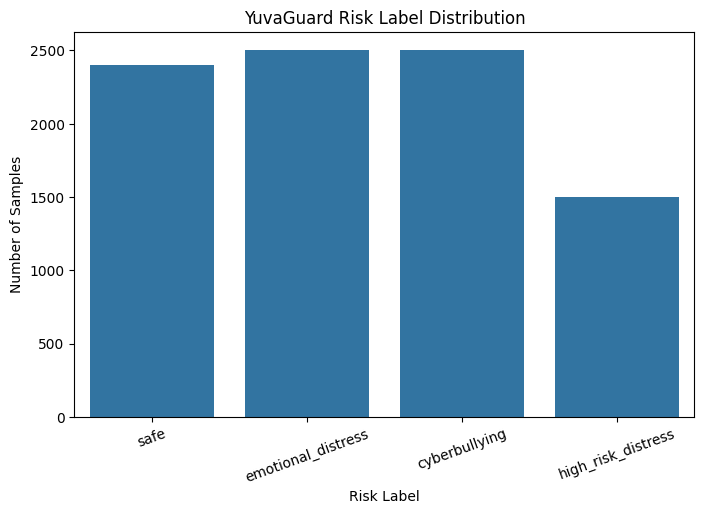

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="risk_label",
    order=[
        "safe",
        "emotional_distress",
        "cyberbullying",
        "high_risk_distress"
    ]
)

plt.title("YuvaGuard Risk Label Distribution")
plt.xlabel("Risk Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=20)
plt.show()

In [ ]:
label_map = {
    "safe": 0,
    "emotional_distress": 1,
    "cyberbullying": 2,
    "high_risk_distress": 3
}

id2label = {
    0: "Safe",
    1: "Emotional Distress",
    2: "Cyberbullying",
    3: "High Risk Distress"
}

label2id = {
    "Safe": 0,
    "Emotional Distress": 1,
    "Cyberbullying": 2,
    "High Risk Distress": 3
}

df["label"] = df["risk_label"].map(label_map)

print("Labels assigned successfully!")
print(df[["risk_label", "label"]].drop_duplicates().sort_values("label"))

Labels assigned successfully!
            risk_label  label
1                 safe      0
9   emotional_distress      1
13       cyberbullying      2
0   high_risk_distress      3


In [ ]:
# Remove rows with missing text or labels
df = df.dropna(subset=["text", "risk_label"])

# Make sure text is stored as a string
df["text"] = df["text"].astype(str)

# Make sure labels are integers
df["label"] = df["label"].astype(int)

# Remove duplicate text entries
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Dataset after cleaning:")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

Dataset after cleaning:
Rows: 8900
Columns: ['id', 'text', 'risk_label', 'risk_level', 'target', 'source', 'label']

Label distribution:
label
0    2400
1    2500
2    2500
3    1500
Name: count, dtype: int64


In [ ]:
# First split: 70% training, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

# Second split: divide the remaining 30% equally
# → 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Dataset split completed!")
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["label"].value_counts().sort_index())


Dataset split completed!
Training samples: 6230
Validation samples: 1335
Test samples: 1335

Training distribution:
label
0    1680
1    1750
2    1750
3    1050
Name: count, dtype: int64

Validation distribution:
label
0    360
1    375
2    375
3    225
Name: count, dtype: int64

Test distribution:
label
0    360
1    375
2    375
3    225
Name: count, dtype: int64


In [ ]:
train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

print("Hugging Face datasets created successfully!")

print("\nTraining dataset:")
print(train_dataset)

print("\nValidation dataset:")
print(val_dataset)

print("\nTest dataset:")
print(test_dataset)

Hugging Face datasets created successfully!

Training dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 6230
})

Validation dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 1335
})

Test dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 1335
})


In [ ]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")
print("Model:", model_name)
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully!
Model: distilbert-base-uncased
Vocabulary size: 30522


In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed successfully!")

print("\nExample tokenized sample:")
print(tokenized_train[0])

Map:   0%|          | 0/6230 [00:00<?, ? examples/s]

Map:   0%|          | 0/1335 [00:00<?, ? examples/s]

Map:   0%|          | 0/1335 [00:00<?, ? examples/s]

Tokenization completed successfully!

Example tokenized sample:
{'text': 'Lately, I noticed that i feel tired and low most of the time and it has been affecting my schoolwork.', 'label': 1, 'input_ids': [101, 9906, 1010, 1045, 4384, 2008, 1045, 2514, 5458, 1998, 2659, 2087, 1997, 1996, 2051, 1998, 2009, 2038, 2042, 12473, 2026, 2082, 6198, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

print("YuvaGuard DistilBERT model loaded successfully!")
print("Number of classes:", model.config.num_labels)
print("Labels:", model.config.id2label)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


YuvaGuard DistilBERT model loaded successfully!
Number of classes: 4
Labels: {0: 'Safe', 1: 'Emotional Distress', 2: 'Cyberbullying', 3: 'High Risk Distress'}


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

print("Evaluation metrics are ready!")

Evaluation metrics are ready!


In [ ]:
training_args = TrainingArguments(
    output_dir="./yuvaguard_model",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=100,

    report_to="none",

    fp16=torch.cuda.is_available()
)

print("Training configuration created successfully!")
print("FP16 enabled:", torch.cuda.is_available())

Training configuration created successfully!
FP16 enabled: True


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

print("YuvaGuard Trainer created successfully!")

YuvaGuard Trainer created successfully!


In [ ]:
print("Starting YuvaGuard model training...")
print("This may take several minutes on the T4 GPU.\n")

train_result = trainer.train()

print("\nTraining completed successfully!")

Starting YuvaGuard model training...
This may take several minutes on the T4 GPU.



Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.005406,0.002017,1.000000,1.000000,1.000000,1.000000
2,0.001351,0.000799,1.000000,1.000000,1.000000,1.000000
3,0.000895,0.000613,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed successfully!


In [ ]:
test_results = trainer.evaluate(tokenized_test)

print("Test Set Results:")
print(f"Accuracy:          {test_results['eval_accuracy']:.4f}")
print(f"Macro Precision:   {test_results['eval_macro_precision']:.4f}")
print(f"Macro Recall:      {test_results['eval_macro_recall']:.4f}")
print(f"Macro F1:          {test_results['eval_macro_f1']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1
0.000895,0.002015,3,1.000000,1.000000,1.000000,1.000000


Test Set Results:
Accuracy:          1.0000
Macro Precision:   1.0000
Macro Recall:      1.0000
Macro F1:          1.0000


In [ ]:
predictions = trainer.predict(tokenized_test)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

true_labels = predictions.label_ids

class_names = [
    "Safe",
    "Emotional Distress",
    "Cyberbullying",
    "High Risk Distress"
]

print("YuvaGuard Classification Report\n")

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

YuvaGuard Classification Report

                    precision    recall  f1-score   support

              Safe     1.0000    1.0000    1.0000       360
Emotional Distress     1.0000    1.0000    1.0000       375
     Cyberbullying     1.0000    1.0000    1.0000       375
High Risk Distress     1.0000    1.0000    1.0000       225

          accuracy                         1.0000      1335
         macro avg     1.0000    1.0000    1.0000      1335
      weighted avg     1.0000    1.0000    1.0000      1335



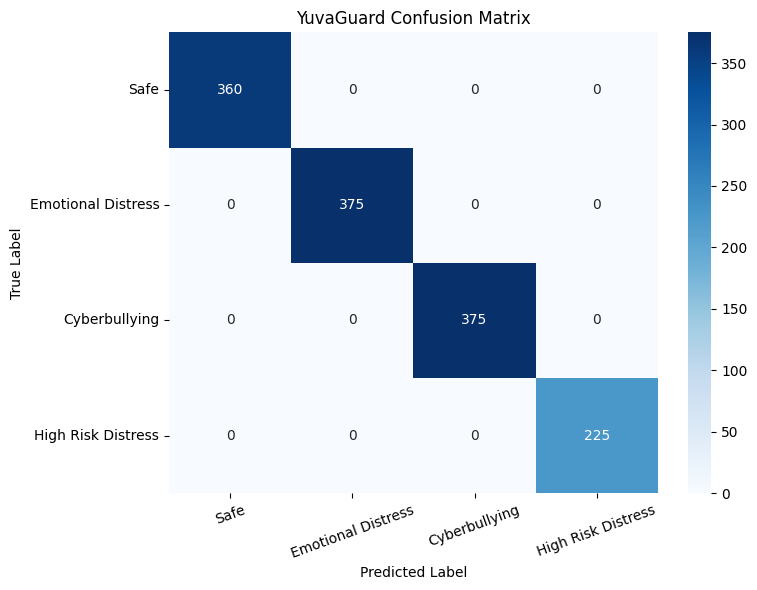

In [ ]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("YuvaGuard Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
MODEL_PATH = "./yuvaguard_distilbert"

trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

print("YuvaGuard model saved successfully!")
print("Model location:", MODEL_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

YuvaGuard model saved successfully!
Model location: ./yuvaguard_distilbert


In [ ]:
def predict_yuvaguard(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move inputs to the same device as the model
    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)
        prediction = torch.argmax(probabilities, dim=-1).item()

    confidence = probabilities[0, prediction].item()

    return {
        "text": text,
        "risk_label": id2label[prediction],
        "confidence": round(confidence, 4)
    }


print("YuvaGuard prediction function is ready!")

YuvaGuard prediction function is ready!


In [ ]:
test_messages = [
    "I had a really good day with my friends at school.",
    "I have been feeling very anxious about school and my exams.",
    "People keep posting embarrassing comments about me in our group chat.",
    "I feel completely hopeless and I don't know how to keep going."
]

print("YuvaGuard Predictions\n")

for message in test_messages:
    result = predict_yuvaguard(message)

    print("Text:", result["text"])
    print("Risk Label:", result["risk_label"])
    print("Confidence:", result["confidence"])
    print("-" * 60)

YuvaGuard Predictions

Text: I had a really good day with my friends at school.
Risk Label: Safe
Confidence: 0.998
------------------------------------------------------------
Text: I have been feeling very anxious about school and my exams.
Risk Label: Emotional Distress
Confidence: 0.9967
------------------------------------------------------------
Text: People keep posting embarrassing comments about me in our group chat.
Risk Label: Cyberbullying
Confidence: 0.9984
------------------------------------------------------------
Text: I feel completely hopeless and I don't know how to keep going.
Risk Label: High Risk Distress
Confidence: 0.9957
------------------------------------------------------------


In [ ]:
def predict_with_probabilities(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)[0]

    results = {}

    for i, probability in enumerate(probabilities):
        results[id2label[i]] = round(probability.item(), 4)

    predicted_class = torch.argmax(probabilities).item()

    return {
        "text": text,
        "prediction": id2label[predicted_class],
        "probabilities": results
    }


result = predict_with_probabilities(
    "People keep posting embarrassing comments about me in our group chat."
)

print("Prediction:", result["prediction"])
print("\nClass probabilities:")

for label, probability in result["probabilities"].items():
    print(f"{label}: {probability:.4f}")

Prediction: Cyberbullying

Class probabilities:
Safe: 0.0005
Emotional Distress: 0.0004
Cyberbullying: 0.9984
High Risk Distress: 0.0006


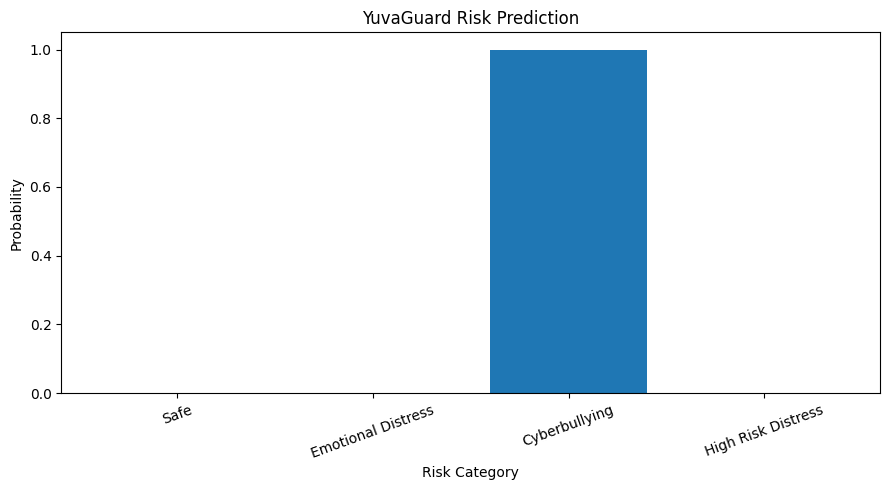

In [ ]:
labels = list(result["probabilities"].keys())
probabilities = list(result["probabilities"].values())

plt.figure(figsize=(9, 5))

plt.bar(labels, probabilities)

plt.title("YuvaGuard Risk Prediction")
plt.xlabel("Risk Category")
plt.ylabel("Probability")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [ ]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(
    class_names=[
        "Safe",
        "Emotional Distress",
        "Cyberbullying",
        "High Risk Distress"
    ]
)

def lime_predict(texts):
    probabilities = []

    for text in texts:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )

        inputs = {
            key: value.to(model.device)
            for key, value in inputs.items()
        }

        model.eval()

        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)

        probabilities.append(probs[0].cpu().numpy())

    return np.array(probabilities)

print("LIME explainer is ready!")

LIME explainer is ready!


In [ ]:
text_to_explain = (
    "People keep posting embarrassing comments about me in our group chat."
)

explanation = explainer.explain_instance(
    text_to_explain,
    lime_predict,
    num_features=10,
    top_labels=4
)

predicted_class = np.argmax(
    lime_predict([text_to_explain])[0]
)

print("Text:")
print(text_to_explain)

print("\nPredicted Class:")
print(id2label[predicted_class])

print("\nLIME Explanation:")
for word, weight in explanation.as_list(label=predicted_class):
    print(f"{word}: {weight:.4f}")

Text:
People keep posting embarrassing comments about me in our group chat.

Predicted Class:
Cyberbullying

LIME Explanation:
comments: 0.0461
chat: 0.0431
posting: 0.0429
People: 0.0400
embarrassing: 0.0262
keep: 0.0123
me: 0.0095
in: 0.0062
our: -0.0055
group: 0.0022


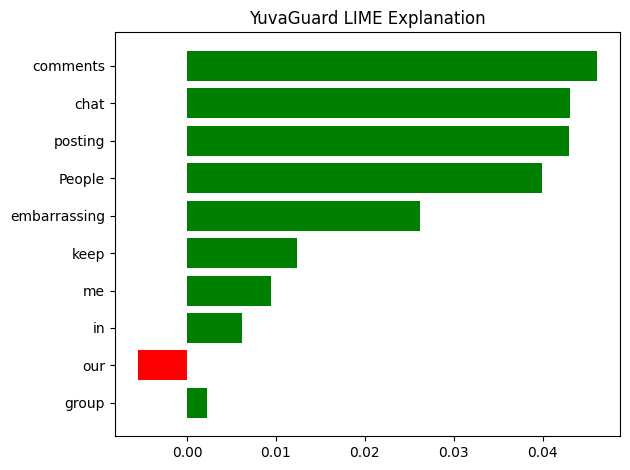

In [ ]:
fig = explanation.as_pyplot_figure(
    label=predicted_class
)

plt.title("YuvaGuard LIME Explanation")
plt.tight_layout()
plt.show()

In [ ]:
text_to_explain = (
    "I have been feeling very anxious about school and my exams."
)

explanation = explainer.explain_instance(
    text_to_explain,
    lime_predict,
    num_features=10,
    top_labels=4
)

predicted_class = np.argmax(
    lime_predict([text_to_explain])[0]
)

print("Text:")
print(text_to_explain)

print("\nPredicted Class:")
print(id2label[predicted_class])

print("\nLIME Explanation:")
for word, weight in explanation.as_list(label=predicted_class):
    print(f"{word}: {weight:.4f}")

Text:
I have been feeling very anxious about school and my exams.

Predicted Class:
Emotional Distress

LIME Explanation:
feeling: 0.2662
anxious: 0.2637
have: 0.2131
exams: 0.1451
school: 0.1345
been: 0.1082
I: 0.0890
very: 0.0857
about: 0.0737
and: -0.0325


In [ ]:
def analyze_yuvaguard(text):
    # Model prediction
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)[0]

    predicted_class = torch.argmax(probabilities).item()
    confidence = probabilities[predicted_class].item()

    # All class probabilities
    class_probabilities = {
        id2label[i]: round(probabilities[i].item(), 4)
        for i in range(len(probabilities))
    }

    # LIME explanation
    explanation = explainer.explain_instance(
        text,
        lime_predict,
        num_features=10,
        top_labels=4
    )

    lime_explanation = [
        {
            "word": word,
            "weight": round(weight, 4)
        }
        for word, weight in explanation.as_list(
            label=predicted_class
        )
    ]

    return {
        "text": text,
        "prediction": id2label[predicted_class],
        "confidence": round(confidence, 4),
        "probabilities": class_probabilities,
        "lime_explanation": lime_explanation
    }


print("Complete YuvaGuard analysis function is ready!")

Complete YuvaGuard analysis function is ready!


In [ ]:
sample_text = (
    "Some students keep making fun of me online and "
    "sharing embarrassing posts about me."
)

analysis = analyze_yuvaguard(sample_text)

print("========== YUVAGUARD ANALYSIS ==========\n")

print("Text:")
print(analysis["text"])

print("\nPredicted Risk:")
print(analysis["prediction"])

print("\nConfidence:")
print(analysis["confidence"])

print("\nClass Probabilities:")
for label, probability in analysis["probabilities"].items():
    print(f"  {label}: {probability}")

print("\nLIME Explanation:")
for item in analysis["lime_explanation"]:
    print(f"  {item['word']}: {item['weight']}")

========== YUVAGUARD ANALYSIS ==========

Text:
Some students keep making fun of me online and sharing embarrassing posts about me.

Predicted Risk:
Cyberbullying

Confidence:
0.9985

Class Probabilities:
  Safe: 0.0005
  Emotional Distress: 0.0005
  Cyberbullying: 0.9985
  High Risk Distress: 0.0006

LIME Explanation:
  posts: 0.0574
  online: 0.0534
  embarrassing: 0.042
  sharing: 0.0336
  keep: 0.0299
  students: 0.028
  Some: 0.0172
  making: 0.0158
  fun: 0.0129
  and: -0.0111


In [ ]:
def display_yuvaguard_result(analysis):
    print("=" * 60)
    print("                 YUVAGUARD RESULT")
    print("=" * 60)

    print(f"\nMessage:")
    print(analysis["text"])

    print(f"\nPredicted Risk:")
    print(f"  {analysis['prediction']}")

    print(f"\nConfidence:")
    print(f"  {analysis['confidence'] * 100:.2f}%")

    print("\nRisk Probabilities:")
    for label, probability in analysis["probabilities"].items():
        print(f"  {label:<22} {probability * 100:>6.2f}%")

    print("\nKey LIME Indicators:")
    for item in analysis["lime_explanation"]:
        direction = "supports" if item["weight"] > 0 else "reduces"
        print(
            f"  {item['word']:<15} "
            f"{item['weight']:>7.4f}  ({direction} prediction)"
        )

    print("\n" + "=" * 60)


display_yuvaguard_result(analysis)

                 YUVAGUARD RESULT

Message:
Some students keep making fun of me online and sharing embarrassing posts about me.

Predicted Risk:
  Cyberbullying

Confidence:
  99.85%

Risk Probabilities:
  Safe                     0.05%
  Emotional Distress       0.05%
  Cyberbullying           99.85%
  High Risk Distress       0.06%

Key LIME Indicators:
  posts            0.0574  (supports prediction)
  online           0.0534  (supports prediction)
  embarrassing     0.0420  (supports prediction)
  sharing          0.0336  (supports prediction)
  keep             0.0299  (supports prediction)
  students         0.0280  (supports prediction)
  Some             0.0172  (supports prediction)
  making           0.0158  (supports prediction)
  fun              0.0129  (supports prediction)
  and             -0.0111  (reduces prediction)



In [ ]:
import os

MODEL_PATH = "./yuvaguard_distilbert"

trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

print("YuvaGuard model package saved!")
print("\nFiles:")

for file_name in sorted(os.listdir(MODEL_PATH)):
    print(" -", file_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

YuvaGuard model package saved!

Files:
 - config.json
 - model.safetensors
 - tokenizer.json
 - tokenizer_config.json
 - training_args.bin


In [ ]:
!pip install -q fastapi uvicorn nest-asyncio

print("FastAPI backend packages installed successfully!")

FastAPI backend packages installed successfully!
